<a href="https://colab.research.google.com/github/mariea-aashif/Statistical-Learning-e22374/blob/main/assignment_6_gaussian_process_regression_and_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression and Linear Regression Assignment

This assignment contains two main parts.

First, Gaussian Process Regression is used to study whether the heating load and cooling load of buildings can be modelled using a single-input Gaussian Process model. The dataset contains building design parameters and two energy-related responses: heating load and cooling load.

Second, Linear Regression is used to predict the predicted energy demand of green buildings using a suitable set of input parameters. The selected parameters are justified using correlation analysis and model performance.

In [23]:
# Install KaggleHub if it is not already available
!pip install kagglehub -q

# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dataset downloading
import kagglehub
import os

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Part 1: Gaussian Process Regression

The first dataset is the Energy Efficiency Dataset. It contains eight building design features, denoted by X1 to X8, and two responses:

- Y1: Heating Load
- Y2: Cooling Load

The objective is to explore whether heating load and cooling load can be modelled using a single-input Gaussian Process Regression model.

In [24]:
# Download the Energy Efficiency Dataset
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print("Files in dataset folder:")
print(os.listdir(path))

# Load the dataset
gpr_df = pd.read_csv(os.path.join(path, "ENB2012_data.csv"))

# Display the first few rows
gpr_df.head()

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset
Files in dataset folder:
['ENB2012_data.csv']


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


### Initial Data Inspection

Before applying Gaussian Process Regression, the structure of the dataset is inspected. This includes checking the number of rows and columns, missing values, data types, and basic statistical information.

In [25]:
# Shape of the dataset
print("Dataset shape:", gpr_df.shape)

# Column names
print("\nColumn names:")
print(gpr_df.columns.tolist())

# Basic information
print("\nDataset information:")
gpr_df.info()

# Check missing values
print("\nMissing values in each column:")
print(gpr_df.isnull().sum())

# Basic statistical summary
gpr_df.describe()

Dataset shape: (768, 10)

Column names:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB

Missing values in each column:
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


The dataset contains eight input features from X1 to X8 and two output responses, Y1 and Y2. In this dataset, Y1 represents the heating load and Y2 represents the cooling load. Since there are no missing values, the dataset can be used directly after scaling the input variables.

### Relationship Between Heating Load and Cooling Load

Since the question asks whether heating load and cooling load can be modelled as a single-parameter Gaussian Process, the relationship between Y1 and Y2 is first examined. If Y1 and Y2 are strongly correlated, then one response may be used as a single input parameter to predict the other using Gaussian Process Regression.

In [26]:
# Correlation between heating load and cooling load
correlation_y1_y2 = gpr_df["Y1"].corr(gpr_df["Y2"])

print("Correlation between Heating Load (Y1) and Cooling Load (Y2):")
print(correlation_y1_y2)

Correlation between Heating Load (Y1) and Cooling Load (Y2):
0.9758618134328573


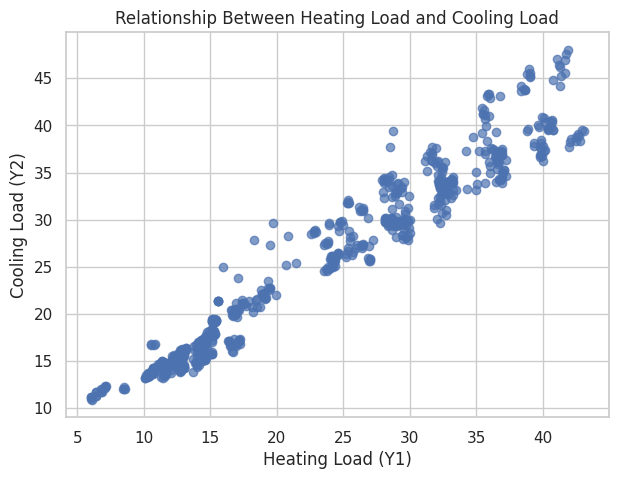

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(gpr_df["Y1"], gpr_df["Y2"], alpha=0.7)
plt.xlabel("Heating Load (Y1)")
plt.ylabel("Cooling Load (Y2)")
plt.title("Relationship Between Heating Load and Cooling Load")
plt.grid(True)
plt.show()

### Gaussian Process Regression Model

Since the correlation between heating load and cooling load is very high, heating load is selected as the single input parameter and cooling load is selected as the output response.

Therefore, the Gaussian Process Regression model is constructed as:

\[
Y2 = f(Y1) + \epsilon
\]

where \(Y1\) is the heating load, \(Y2\) is the cooling load, \(f\) is the unknown function modelled by the Gaussian Process, and \(\epsilon\) represents noise.

In [28]:
# Input and output for single-parameter GPR
X_gpr = gpr_df[["Y1"]].values      # Heating Load as input
y_gpr = gpr_df["Y2"].values        # Cooling Load as output

# Train-test split
X_train_gpr, X_test_gpr, y_train_gpr, y_test_gpr = train_test_split(
    X_gpr, y_gpr, test_size=0.2, random_state=42
)

# Scale the input variable
scaler_gpr = StandardScaler()
X_train_gpr_scaled = scaler_gpr.fit_transform(X_train_gpr)
X_test_gpr_scaled = scaler_gpr.transform(X_test_gpr)

print("Training samples:", X_train_gpr.shape[0])
print("Testing samples:", X_test_gpr.shape[0])

Training samples: 614
Testing samples: 154


### Kernel Selection

A Gaussian Process model requires a kernel function to describe the covariance between different input points. In this model, an RBF kernel is used because the scatter plot suggests a smooth nonlinear relationship between heating load and cooling load.

A White Kernel is also included to represent observational noise in the data.

In [29]:
# Define the kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(
    noise_level=1.0,
    noise_level_bounds=(1e-5, 1e2)
)

# Create the Gaussian Process Regression model
gpr_model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

# Fit the model
gpr_model.fit(X_train_gpr_scaled, y_train_gpr)

print("Optimized kernel:")
print(gpr_model.kernel_)

Optimized kernel:
22.2**2 * RBF(length_scale=0.154) + WhiteKernel(noise_level=2.56)


In [30]:
# Make predictions
y_pred_gpr, y_std_gpr = gpr_model.predict(X_test_gpr_scaled, return_std=True)

# Evaluation metrics
gpr_mse = mean_squared_error(y_test_gpr, y_pred_gpr)
gpr_rmse = np.sqrt(gpr_mse)
gpr_mae = mean_absolute_error(y_test_gpr, y_pred_gpr)
gpr_r2 = r2_score(y_test_gpr, y_pred_gpr)

print("Gaussian Process Regression Performance")
print("---------------------------------------")
print("Mean Squared Error (MSE):", gpr_mse)
print("Root Mean Squared Error (RMSE):", gpr_rmse)
print("Mean Absolute Error (MAE):", gpr_mae)
print("R² Score:", gpr_r2)

Gaussian Process Regression Performance
---------------------------------------
Mean Squared Error (MSE): 2.800123841853347
Root Mean Squared Error (RMSE): 1.6733570574905248
Mean Absolute Error (MAE): 1.21461218231266
R² Score: 0.9697797610112676


### GPR Model Performance

The Gaussian Process Regression model gives a high \(R^2\) value, which indicates that heating load is a strong single input parameter for predicting cooling load. The optimized kernel contains an RBF component and a White Kernel component. The RBF kernel models the smooth relationship between heating load and cooling load, while the White Kernel accounts for noise in the observations.

Since the \(R^2\) score is close to 1 and the prediction errors are relatively small, the results suggest that heating load and cooling load have a strong relationship and can be modelled using a single-parameter Gaussian Process.

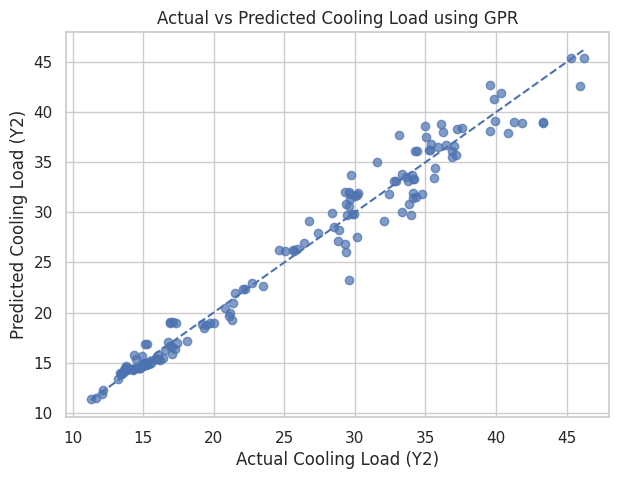

In [31]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_gpr, y_pred_gpr, alpha=0.7)

# Perfect prediction reference line
min_value = min(y_test_gpr.min(), y_pred_gpr.min())
max_value = max(y_test_gpr.max(), y_pred_gpr.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Cooling Load (Y2)")
plt.ylabel("Predicted Cooling Load (Y2)")
plt.title("Actual vs Predicted Cooling Load using GPR")
plt.grid(True)
plt.show()

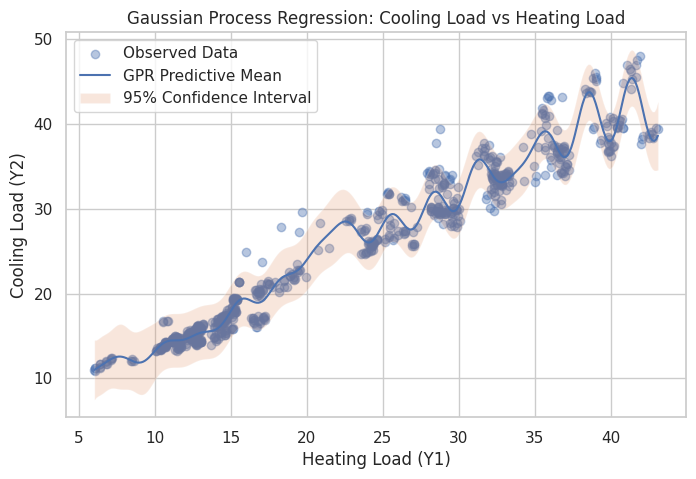

In [32]:
# Sort the original input values for a smooth curve
X_curve = np.linspace(X_gpr.min(), X_gpr.max(), 300).reshape(-1, 1)
X_curve_scaled = scaler_gpr.transform(X_curve)

# Predict mean and standard deviation
y_curve_mean, y_curve_std = gpr_model.predict(X_curve_scaled, return_std=True)

plt.figure(figsize=(8, 5))

# Plot original data
plt.scatter(X_gpr, y_gpr, alpha=0.4, label="Observed Data")

# Plot predictive mean
plt.plot(X_curve, y_curve_mean, label="GPR Predictive Mean")

# Plot 95% confidence interval
plt.fill_between(
    X_curve.ravel(),
    y_curve_mean - 1.96 * y_curve_std,
    y_curve_mean + 1.96 * y_curve_std,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Heating Load (Y1)")
plt.ylabel("Cooling Load (Y2)")
plt.title("Gaussian Process Regression: Cooling Load vs Heating Load")
plt.legend()
plt.grid(True)
plt.show()

### Conclusion for Gaussian Process Regression

The correlation analysis showed a strong positive relationship between heating load and cooling load. Therefore, heating load was selected as the single input parameter and cooling load was selected as the output response for the Gaussian Process Regression model.

The model achieved a high \(R^2\) score of approximately 0.97, showing that most of the variation in cooling load can be explained using heating load alone. The actual vs predicted plot also shows that the predicted values are close to the actual values. The uncertainty band gives additional information about the confidence of the predictions.

Therefore, it is reasonable to conclude that heating load and cooling load can be modelled as a single-parameter Gaussian Process. However, this model only uses the relationship between the two output variables. A more complete model could use the original building design features X1 to X8 as inputs to predict both heating and cooling loads.

## Part 2: Linear Regression

The second part of the assignment uses the Green Building Multi-Source Environment Dataset. The objective is to predict the `predicted_energy_demand` using a suitable set of other data parameters.

Linear Regression is used because the task is to explore whether the target variable can be represented using a linear relationship with selected input features.

In [33]:
# Download the Green Building Multi-Source Environment Dataset
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print("Files in dataset folder:")
print(os.listdir(path))

# Load the dataset
lr_df = pd.read_csv(os.path.join(path, "green_building_dataset.csv"))

# Display the first few rows
lr_df.head()

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset
Files in dataset folder:
['green_building_dataset.csv']


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


### Initial Data Inspection

The dataset is inspected to identify the available variables, missing values, data types, and the general structure of the data. This helps in selecting suitable parameters for predicting `predicted_energy_demand`.

In [34]:
# Shape of the dataset
print("Dataset shape:", lr_df.shape)

# Column names
print("\nColumn names:")
print(lr_df.columns.tolist())

# Dataset information
print("\nDataset information:")
lr_df.info()

# Missing values
print("\nMissing values in each column:")
print(lr_df.isnull().sum())

# Statistical summary
lr_df.describe()

Dataset shape: (2400, 19)

Column names:
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand', 'predicted_comfort_index']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   indoor_temperature       2400 non-null   float64
 1   indoor_humidity          2400 non-null   float64
 2   co2_concentration        2400 non-null   float64
 3   indoor_lighting          2400 non-null   float64
 4   indoor_noise             2400 non-null   float64
 5   outdoor_temperature      2400 non-null   float64
 6   outdoor_humidity     

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932


### Correlation Analysis

To select suitable parameters for the Linear Regression model, the correlation between each numerical variable and `predicted_energy_demand` is calculated. Variables with stronger correlation are more useful for a linear prediction model.

In [35]:
# Select only numerical columns
numeric_lr_df = lr_df.select_dtypes(include=[np.number])

# Correlation with the target variable
target_column = "predicted_energy_demand"

correlation_with_target = numeric_lr_df.corr()[target_column].sort_values(ascending=False)

print("Correlation of numerical variables with predicted_energy_demand:")
print(correlation_with_target)

Correlation of numerical variables with predicted_energy_demand:
predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64


### Selection of Input Parameters

Based on the correlation analysis, the variables with the strongest positive relationship with `predicted_energy_demand` are selected.

The selected input parameters are:

- `ventilation_rate`
- `electricity_consumption`
- `cooling_energy`
- `heating_energy`

These variables are suitable because they are physically related to building energy demand. Ventilation affects the amount of conditioned air required, electricity consumption reflects the overall energy usage, and heating and cooling energy are directly connected to the building's thermal load.

Variables such as `equipment_load`, `occupancy`, and `activity_level` show much weaker correlation with the target variable, so they are not included in the main Linear Regression model.

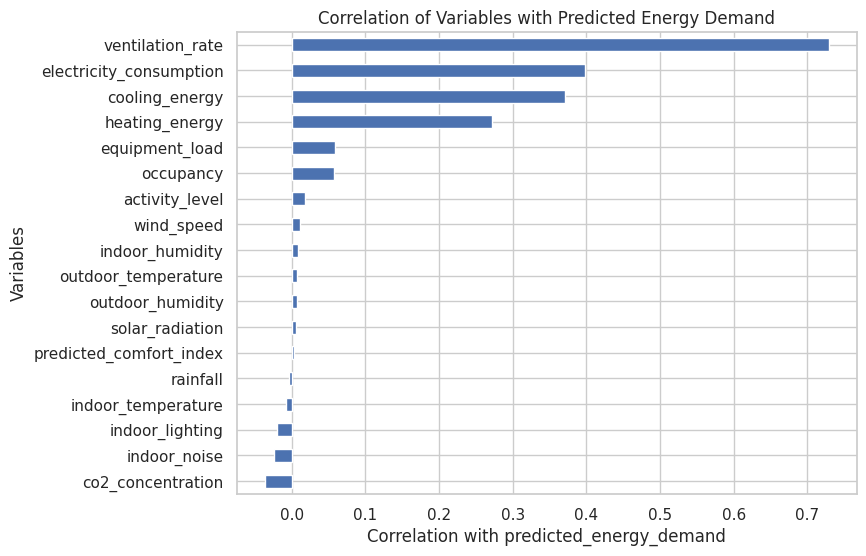

In [36]:
plt.figure(figsize=(8, 6))

correlation_with_target.drop("predicted_energy_demand").sort_values().plot(kind="barh")

plt.xlabel("Correlation with predicted_energy_demand")
plt.ylabel("Variables")
plt.title("Correlation of Variables with Predicted Energy Demand")
plt.grid(True)
plt.show()

In [37]:
# Selected input features
selected_features = [
    "ventilation_rate",
    "electricity_consumption",
    "cooling_energy",
    "heating_energy"
]

# Input and output variables
X_lr = lr_df[selected_features]
y_lr = lr_df["predicted_energy_demand"]

# Train-test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

# Scale the input features
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

print("Selected features:")
print(selected_features)

print("\nTraining samples:", X_train_lr.shape[0])
print("Testing samples:", X_test_lr.shape[0])

Selected features:
['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']

Training samples: 1920
Testing samples: 480


### Linear Regression Model

A Linear Regression model is fitted using the selected input parameters. The model assumes that the predicted energy demand can be approximated as a linear combination of the selected variables.

The model has the form:

\[
\hat{Y} = \beta_0 + \beta_1X_1 + \beta_2X_2 + \beta_3X_3 + \beta_4X_4
\]

where \(\hat{Y}\) is the predicted energy demand and \(X_1, X_2, X_3,\) and \(X_4\) are the selected input parameters.

In [38]:
# Create and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_lr_scaled, y_train_lr)

# Display intercept and coefficients
print("Intercept:", lr_model.intercept_)

print("\nModel coefficients:")
for feature, coefficient in zip(selected_features, lr_model.coef_):
    print(feature, ":", coefficient)

Intercept: 33.73598333140771

Model coefficients:
ventilation_rate : 7.14126358743798
electricity_consumption : 4.171550832778864
cooling_energy : 3.5548058866357803
heating_energy : 2.832767843820127


### Interpretation of Model Coefficients

The fitted Linear Regression model gives positive coefficients for all selected input variables. This means that, within the fitted model, an increase in ventilation rate, electricity consumption, cooling energy, or heating energy tends to increase the predicted energy demand.

Among the selected variables, `ventilation_rate` has the largest coefficient after scaling. This suggests that it has the strongest influence on the predicted energy demand in this linear model.

In [39]:
# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_lr_scaled)

# Evaluation metrics
lr_mse = mean_squared_error(y_test_lr, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test_lr, y_pred_lr)
lr_r2 = r2_score(y_test_lr, y_pred_lr)

print("Linear Regression Performance")
print("-----------------------------")
print("Mean Squared Error (MSE):", lr_mse)
print("Root Mean Squared Error (RMSE):", lr_rmse)
print("Mean Absolute Error (MAE):", lr_mae)
print("R² Score:", lr_r2)

Linear Regression Performance
-----------------------------
Mean Squared Error (MSE): 4.754916373353425
Root Mean Squared Error (RMSE): 2.1805770734723926
Mean Absolute Error (MAE): 1.7165846905674065
R² Score: 0.9490675290238755


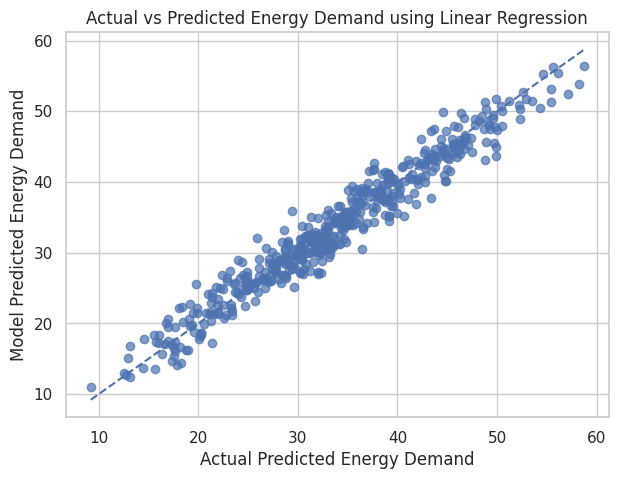

In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.7)

# Perfect prediction reference line
min_value = min(y_test_lr.min(), y_pred_lr.min())
max_value = max(y_test_lr.max(), y_pred_lr.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Predicted Energy Demand")
plt.ylabel("Model Predicted Energy Demand")
plt.title("Actual vs Predicted Energy Demand using Linear Regression")
plt.grid(True)
plt.show()

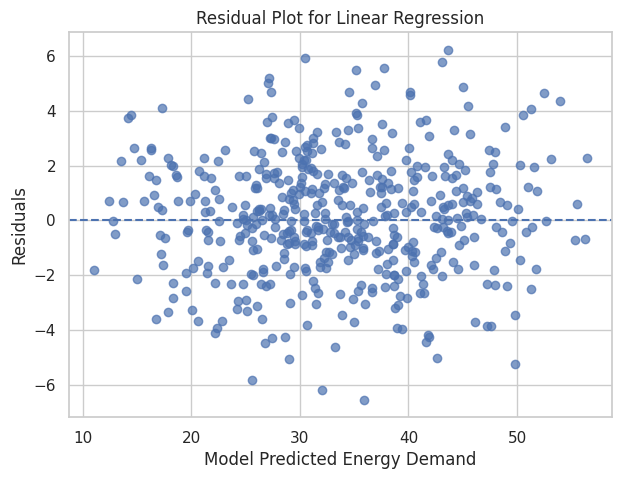

In [41]:
# Calculate residuals
residuals_lr = y_test_lr - y_pred_lr

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.7)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Model Predicted Energy Demand")
plt.ylabel("Residuals")
plt.title("Residual Plot for Linear Regression")
plt.grid(True)
plt.show()

### Linear Regression Model Performance

The Linear Regression model achieved an \(R^2\) score of approximately 0.95. This means that about 95% of the variation in `predicted_energy_demand` can be explained using the selected input parameters.

The selected variables were:

- `ventilation_rate`
- `electricity_consumption`
- `cooling_energy`
- `heating_energy`

These variables were selected because they showed the strongest correlations with `predicted_energy_demand` and are also physically meaningful in relation to building energy usage.

The RMSE value is approximately 2.18, which indicates that the model predictions are reasonably close to the actual values. Therefore, a linear relationship is suitable for predicting `predicted_energy_demand` using the selected parameters.

In [42]:
# Create a dataframe for model coefficients
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": lr_model.coef_
})

# Sort by absolute coefficient value
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Absolute Coefficient", ascending=False)

coef_df

,Feature,Coefficient,Absolute Coefficient
0,ventilation_rate,7.141264,7.141264
1,electricity_consumption,4.171551,4.171551
2,cooling_energy,3.554806,3.554806
3,heating_energy,2.832768,2.832768


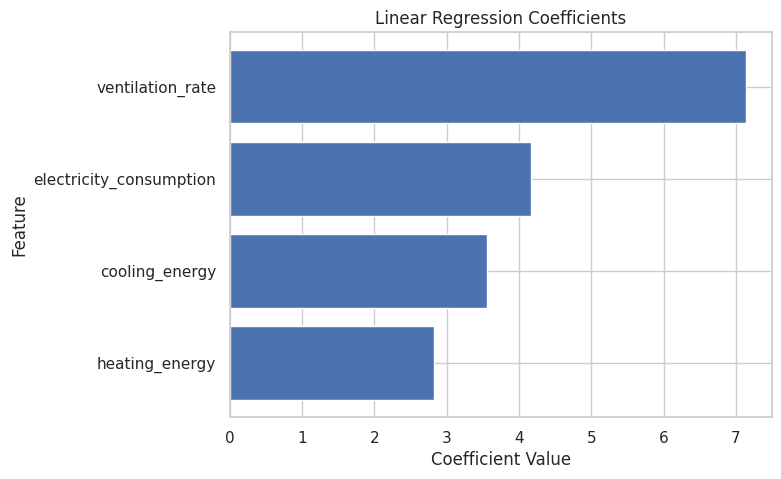

In [43]:
plt.figure(figsize=(7, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

### Final Discussion

The assignment considered two regression approaches: Gaussian Process Regression and Linear Regression.

For the Gaussian Process Regression part, heating load was used as a single input parameter to model cooling load. This choice was supported by the high correlation between heating load and cooling load. The GPR model produced a high \(R^2\) value of approximately 0.97, showing that cooling load can be predicted effectively from heating load alone. The use of a Gaussian Process also provides uncertainty information through the confidence interval, which is an advantage over ordinary regression methods.

For the Linear Regression part, the target variable was `predicted_energy_demand`. Correlation analysis was used to select the most suitable input parameters. The selected variables were `ventilation_rate`, `electricity_consumption`, `cooling_energy`, and `heating_energy`. These variables were selected because they showed the strongest relationship with the target variable and have a clear physical connection to building energy demand.

The Linear Regression model achieved an \(R^2\) score of approximately 0.95, indicating that the selected input variables explain most of the variation in the target variable. The residual plot can be used to check whether the errors are randomly distributed around zero. If the residuals are mostly scattered without a clear pattern, then the linear model is suitable.

Overall, both models gave strong results. The Gaussian Process Regression model was useful for modelling the nonlinear relationship between heating load and cooling load while also giving uncertainty estimates. The Linear Regression model was useful for producing a simple, interpretable relationship between selected building parameters and predicted energy demand.

## Conclusion

Heating load and cooling load showed a strong positive relationship, with a correlation of approximately 0.976. Therefore, heating load was suitable as a single input parameter for modelling cooling load using Gaussian Process Regression. The GPR model achieved an \(R^2\) value of approximately 0.97, showing very good predictive performance.

For the Linear Regression part, `ventilation_rate`, `electricity_consumption`, `cooling_energy`, and `heating_energy` were selected as input parameters for predicting `predicted_energy_demand`. The Linear Regression model achieved an \(R^2\) value of approximately 0.95, showing that the selected parameters can explain most of the variation in the target variable.

Therefore, Gaussian Process Regression is suitable for the single-parameter heating-cooling load relationship, while Linear Regression is suitable for an interpretable prediction model for energy demand using selected building parameters.